In [1]:
import cv2
import os
import numpy as np
import torch
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet101, DeepLabV3_ResNet101_Weights
import matplotlib.pyplot as plt

이미지 크기: (349, 501, 3)


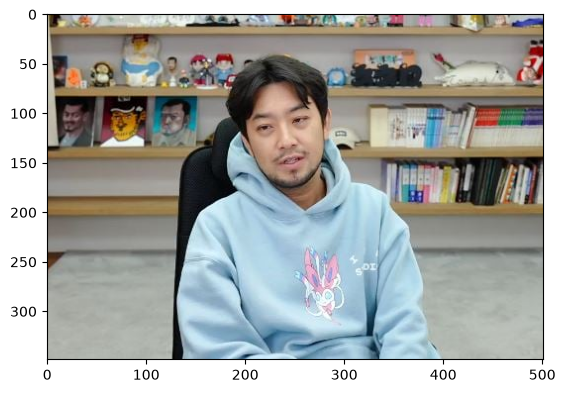

In [2]:
base_dir = os.getcwd()
img_path = os.path.join(base_dir, "image", "chimman.jpg")
img_orig = cv2.imread(img_path)

print(f"이미지 크기: {img_orig.shape}")

plt.imshow(cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB))
plt.show()

## 모델 다운로드

In [3]:
weights = DeepLabV3_ResNet101_Weights.DEFAULT
model = deeplabv3_resnet101(weights=weights).eval()

0.1%

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet101_coco-586e9e4e.pth" to C:\Users\heeji/.cache\torch\hub\checkpoints\deeplabv3_resnet101_coco-586e9e4e.pth


100.0%


In [4]:
# 모델 전처리
transform = T.Compose([
    T.ToPILImage(),
    T.Resize((520, 520)),  # 모델 입력 크기 (고정)
    T.ToTensor(),
])

## 이미지 전처리

In [5]:
input_tensor = transform(cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)).unsqueeze(0)

In [6]:
%%time
with torch.no_grad():
    output = model(input_tensor)["out"][0]
    output_predictions = output.argmax(0).byte().cpu().numpy()

# 원본 크기로 Resize
output_predictions_resized = cv2.resize(output_predictions, (img_orig.shape[1], img_orig.shape[0]), interpolation=cv2.INTER_NEAREST)

CPU times: total: 11 s
Wall time: 2.61 s


## 인물 객체 추출

In [7]:
#pascalvoc 데이터의 라벨종류
LABEL_NAMES = [
    'background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus',
    'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike',
    'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tv'
]
len(LABEL_NAMES)

21

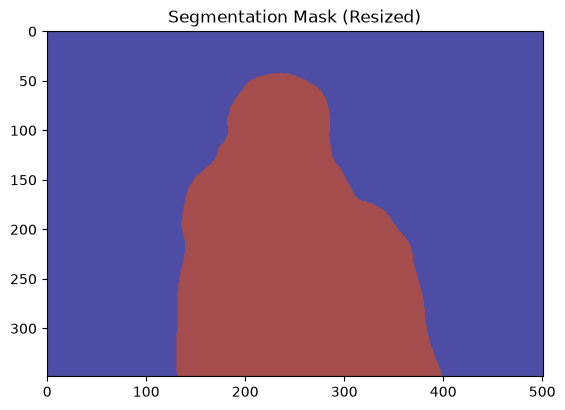

In [8]:
plt.imshow(output_predictions_resized, cmap="jet", alpha=0.7)
plt.title("Segmentation Mask (Resized)")
plt.show()

In [9]:
unique_classes = np.unique(output_predictions_resized)
unique_classes

array([ 0, 15], dtype=uint8)

In [10]:
for class_id in unique_classes:
    print(LABEL_NAMES[class_id])

background
person


In [11]:
#컬러맵 만들기
colormap = np.zeros((256, 3), dtype=int)
ind = np.arange(256, dtype=int)

for shift in reversed(range(8)):
    for channel in range(3):
        colormap[:, channel] |= ((ind >> channel) & 1) << shift
    ind >>= 3

colormap[:20]  # 생성한 20개의 컬러맵 출력

array([[  0,   0,   0],
       [128,   0,   0],
       [  0, 128,   0],
       [128, 128,   0],
       [  0,   0, 128],
       [128,   0, 128],
       [  0, 128, 128],
       [128, 128, 128],
       [ 64,   0,   0],
       [192,   0,   0],
       [ 64, 128,   0],
       [192, 128,   0],
       [ 64,   0, 128],
       [192,   0, 128],
       [ 64, 128, 128],
       [192, 128, 128],
       [  0,  64,   0],
       [128,  64,   0],
       [  0, 192,   0],
       [128, 192,   0]])

In [12]:
colormap[15] #컬러맵 15에 해당하는 배열 출력

array([192, 128, 128])

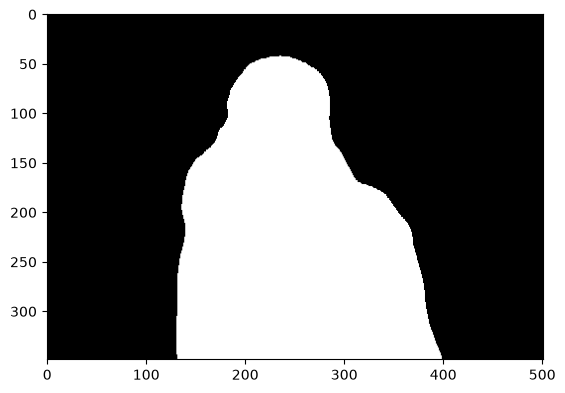

In [13]:
# output의 픽셀 별로 예측된 class가 사람이라면 1(True), 다르다면 0(False)
seg_map = (output_predictions_resized == 15)  # 클래스 ID 15 (사람)
img_mask = seg_map.astype(np.uint8) * 255  # 255 값으로 변환
color_mask = cv2.applyColorMap(img_mask, cv2.COLORMAP_JET)

plt.imshow(img_mask, cmap='gray')  # 흑백으로 표시
plt.show()

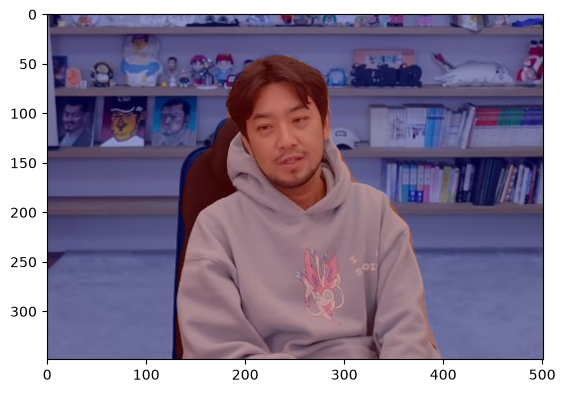

In [14]:
# 원본 0.6, 마스크 0.4로 섞음
img_show = cv2.addWeighted(img_orig, 0.6, color_mask, 0.4, 0.0)

plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.show()

## 배경 블러 처리

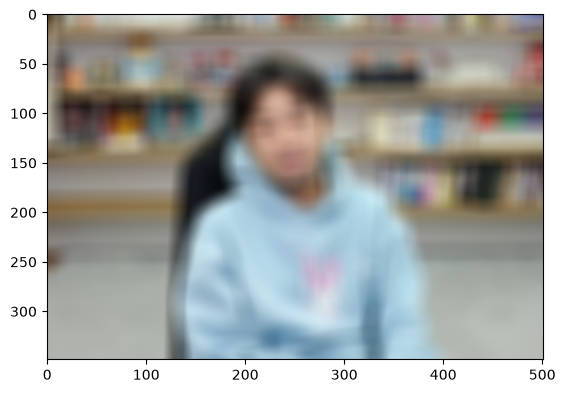

In [15]:
# (20,20): blurring kernel size
# 값이 클수록 blur 강도 증가
img_orig_blur = cv2.blur(img_orig, (20, 20))

plt.imshow(cv2.cvtColor(img_orig_blur, cv2.COLOR_BGR2RGB))
plt.show()

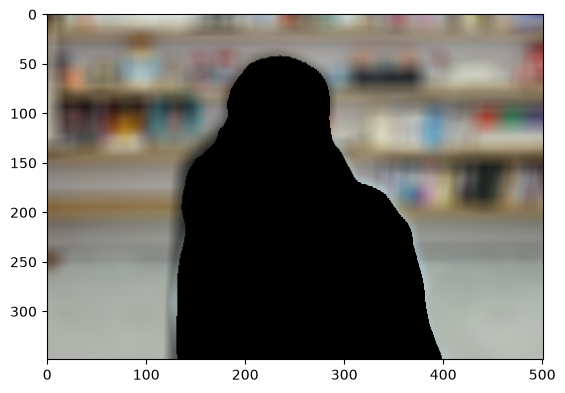

In [16]:
img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)

# cv2.bitwise_not(): 이미지가 반전 (배경 0, 인물 255 -> 배경 255, 인물 0)
img_bg_mask = cv2.bitwise_not(img_mask_color)

# cv2.bitwise_and(): 배경만 있는 영상을 얻음
img_bg_blur = cv2.bitwise_and(img_orig_blur, img_bg_mask)
plt.imshow(cv2.cvtColor(img_bg_blur, cv2.COLOR_BGR2RGB))
plt.show()

## 흐린 배경과 원본 합성

### 흐린 배경 + 원본 사람

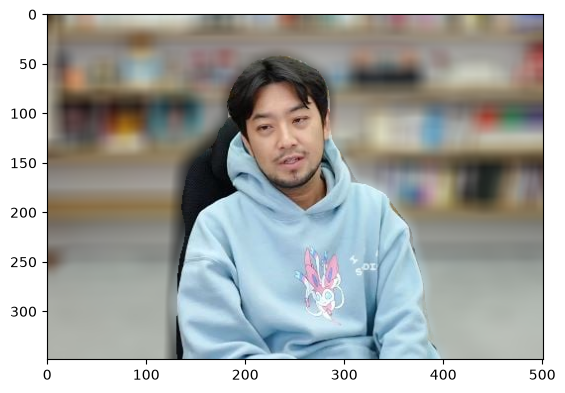

In [17]:
# np.where(조건, 참일때, 거짓일때)
img_concat = np.where(img_mask_color==255, img_orig, img_bg_blur)

plt.imshow(cv2.cvtColor(img_concat, cv2.COLOR_BGR2RGB))
plt.show()

In [19]:
# 이미지 저장
save_path = os.path.join(base_dir, "image", "chimman_blur.jpg")
os.makedirs(os.path.dirname(save_path), exist_ok=True)  # 폴더 없으면 생성

cv2.imwrite(save_path, img_concat)

True

### 원본 배경 + 흐린 사람

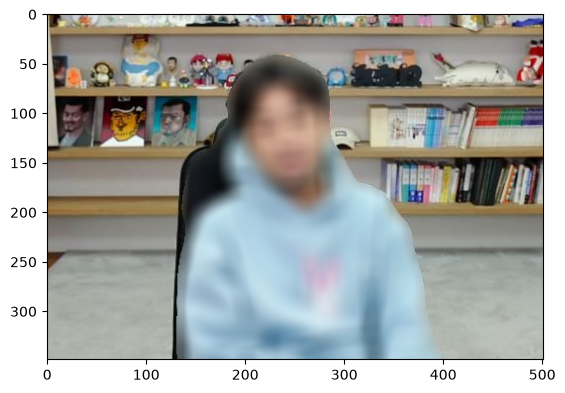

In [20]:
img_concat = np.where(img_mask_color == 255, img_orig_blur, img_orig)
plt.imshow(cv2.cvtColor(img_concat, cv2.COLOR_BGR2RGB))
plt.show()

---

## 인물 사진 문제점

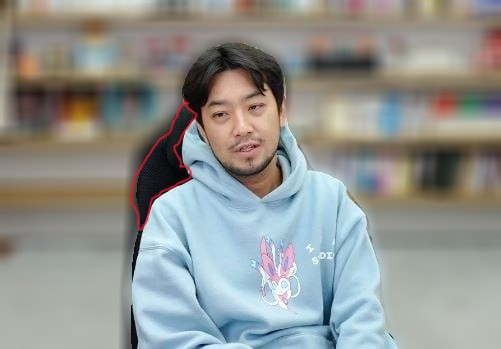

위 이미지의 의자 일부가 블러 처리 되지 않았다.

---

## 해결 방안

### 원인

의자 후보 픽셀 수: 4391

[의자 후보 영역] N=4391  — 클래스 평균 softmax 확률 top5
   person      (id 15): 0.650
   background  (id  0): 0.230
   chair       (id  9): 0.108
   sofa        (id 18): 0.010
   tv          (id 20): 0.001

[확실한 인물 영역] N=43844  — 클래스 평균 softmax 확률 top5
   person      (id 15): 0.999
   background  (id  0): 0.001
   chair       (id  9): 0.000
   cat         (id  8): 0.000
   sofa        (id 18): 0.000


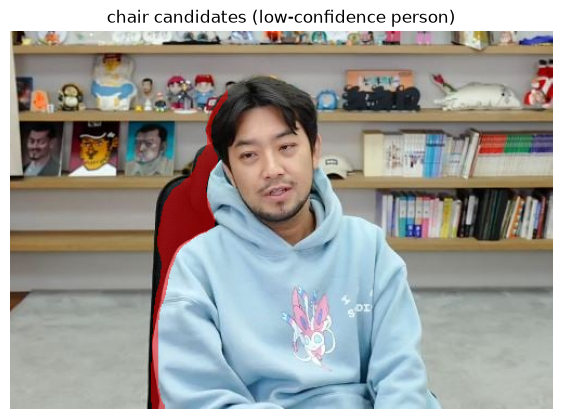

In [23]:
import torch.nn.functional as F

# 1. softmax 확률맵 (21개 클래스)
with torch.no_grad():
    logits = model(input_tensor)["out"][0]        # (21, 520, 520)
prob = F.softmax(logits, dim=0).cpu().numpy()      # (21, 520, 520)

H, W = img_orig.shape[:2]
prob_full = np.stack([cv2.resize(prob[c], (W, H), interpolation=cv2.INTER_LINEAR)
                      for c in range(len(LABEL_NAMES))])   # (21, H, W)
argmax_full = prob_full.argmax(0)
person_prob = prob_full[15]

# 2. 의자 후보 = argmax는 person인데 확신도 낮고(<0.9) 왼쪽에 위치한 픽셀
xs = np.arange(W)[None, :].repeat(H, 0)
chair_region = (argmax_full == 15) & (person_prob < 0.9) & (xs < W * 0.40)
person_core  = (person_prob > 0.99)   # 확실한 인물(비교용)
print("의자 후보 픽셀 수:", int(chair_region.sum()))

# 3) 영역별 클래스 평균 확률 top5 출력
def class_profile(mask, name):
    mean = prob_full[:, mask].mean(axis=1)         # (21,) 영역 내 평균 확률
    print(f"\n[{name}] N={int(mask.sum())}  — 클래스 평균 softmax 확률 top5")
    for c in np.argsort(mean)[::-1][:5]:
        print(f"   {LABEL_NAMES[c]:12s}(id {c:2d}): {mean[c]:.3f}")

class_profile(chair_region, "의자 후보 영역")
class_profile(person_core,  "확실한 인물 영역")

# 4) 의자 후보 픽셀 위치 시각화
vis = img_orig.copy()
vis[chair_region] = (0, 0, 255)
plt.figure(figsize=(7, 5))
plt.imshow(cv2.cvtColor(cv2.addWeighted(img_orig, 0.5, vis, 0.5, 0), cv2.COLOR_BGR2RGB))
plt.title("chair candidates (low-confidence person)")
plt.axis("off")
plt.show()

의자 영역의 `person` 클래스 평균 확률은 **0.650**으로, 실제 인물 영역의 평균 확률(**0.999**)보다 상대적으로 낮다.

그럼에도 `output.argmax(0)`은 확률의 높고 낮음과 무관하게 1등 클래스로 확정하기 때문에, `person`이 근소하게 1등이던 저확신 의자 픽셀까지 인물로 분류된다. 이것이 의자가 마스크에 포함되어 블러 처리되지 않은 원인이다.

### 해결 방안

`argmax`로 1등 클래스를 확정하는 대신, `softmax`로 `person` 확률맵을 만든 뒤 확신도 threshold(=0.80)로 마스킹한다.

이렇게 하면 `person`이 근소하게 1등이던 저확신 픽셀은 기준을 넘지 못해 마스크에서 제외되고, 확률이 높은 실제 인물만 남는다.

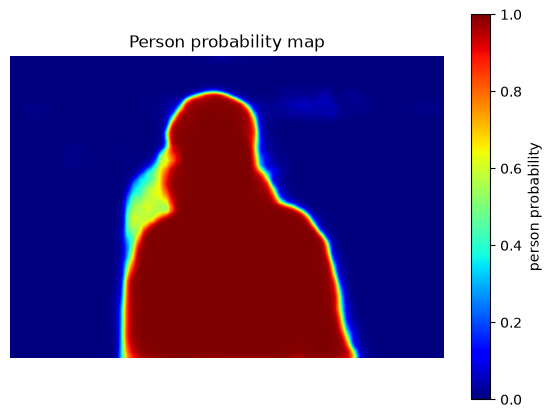

In [47]:
import torch.nn.functional as F

# softmax 로 person(15) 확률맵을 생성
with torch.no_grad():
    output = model(input_tensor)["out"][0]
person_prob = F.softmax(output, dim=0)[15]

# 원본 크기로 복원
person_prob = cv2.resize(person_prob.cpu().numpy(),
                         (img_orig.shape[1], img_orig.shape[0]),
                         interpolation=cv2.INTER_LINEAR)

# 확률맵 시각화
plt.figure(figsize=(7, 5))
plt.imshow(person_prob, cmap="jet", vmin=0, vmax=1)
plt.colorbar(label="person probability")
plt.title("Person probability map")
plt.axis("off")
plt.show()

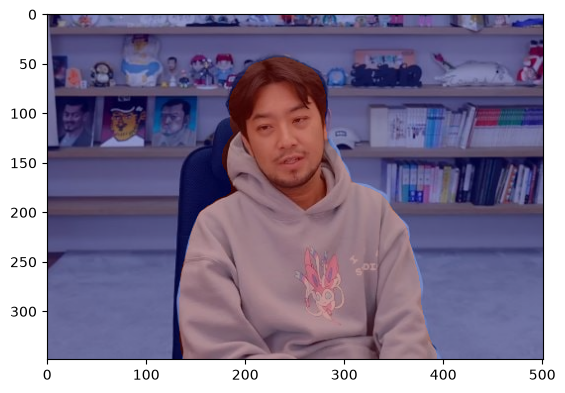

In [44]:
#  0.80 threshold → 저확신 의자 픽셀 제거
seg_map = (person_prob > 0.80)
img_mask = seg_map.astype(np.uint8) * 255
color_mask = cv2.applyColorMap(img_mask, cv2.COLORMAP_JET)

# 원본 0.6, 마스크 0.4로 섞음
img_show = cv2.addWeighted(img_orig, 0.6, color_mask, 0.4, 0.0)

plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.show()

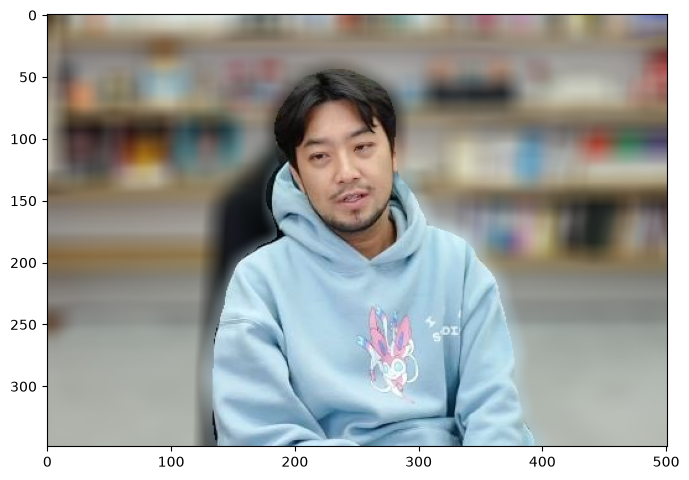

In [46]:
# 배경 블러 처리
img_orig_blur = cv2.blur(img_orig, (20, 20))

# 마스크를 3채널로 변환
img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)

# np.where(조건, 참일때, 거짓일때)
img_concat = np.where(img_mask_color == 255, img_orig, img_orig_blur)

# 시각화
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(img_concat, cv2.COLOR_BGR2RGB))
plt.show()

### 결과

threshold=0.80을 적용해 의자를 배경과 함께 블러 처리하는 데 성공했다.
다만 확신도가 다소 낮은 머리카락 일부가 함께 블러되었고, 반대로 인물 옆 경계 일부는 블러가 덜 적용되는 한계가 남았다.